In [1]:
pip install sshtunnel

Note: you may need to restart the kernel to use updated packages.


In [2]:
import mysql.connector
import numpy as np
import pandas as pd
import random
from sklearn.metrics.pairwise import cosine_similarity
#import matplotlib.pyplot as plt

import sshtunnel
#from sshtunnel import SSHTunnelForwarder
from surprise import Dataset, Reader



c:\Python310\lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Python310\lib\site-packages\paramiko\transport.py:253: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


In [3]:
#NOVO
import sys
print(sys.executable)
print(sys.version)

print("---")
import matplotlib.pyplot as plt
plt.ion()
import seaborn as sns
import re
from statsmodels.graphics.mosaicplot import mosaic
import squarify

print("Tudo importado com sucesso!")

c:\Python310\python.exe
3.10.2 (tags/v3.10.2:a58ebcc, Jan 17 2022, 14:12:15) [MSC v.1929 64 bit (AMD64)]
---
Tudo importado com sucesso!


In [ ]:

# Connect to MySQL and Load Data
with sshtunnel.SSHTunnelForwarder(
    ('rachel.waik.eu', 22),
    ssh_username='emorecsys',
    ssh_password='TMgx64gP8iD37wmx3wdn',
    remote_bind_address=('127.0.0.1', 3306)
) as tunnel:
    connection = mysql.connector.connect(
        user='emorecsys_reader',
        password='dDoZzsLz3r7pkJ9YooXn',
        host='127.0.0.1',
        port=tunnel.local_bind_port,
        database='emorecsys',
        use_pure=True
    )
    query1 = "SELECT * FROM ratings"
    df_ratings = pd.read_sql(query1, con=connection)
    print(df_ratings)
    query2 = "SELECT * FROM surveys"
    df_surveys = pd.read_sql(query2, con=connection)
    print(df_surveys)
    connection.close()


        id  id_photo  id_survey  like_bool  anger  fear  disgust  sadness  \
0        1      1754          1          1      0     0        0        0   
1        2      1785          1          1      0     0        0        2   
2        3       123          1          0      0     0        0        4   
3        4      2315          1          0      0     0        0        2   
4        5      1548          1          0      0     0        0        0   
...    ...       ...        ...        ...    ...   ...      ...      ...   
5860  5861       918        391          1      0     0        0        0   
5861  5862      1398        391          1      0     0        0        0   
5862  5863      2441        391          1      0     0        0        0   
5863  5864      2739        391          1      0     0        0        0   
5864  5865      1826        391          1      0     0        0        0   

      happiness  surprise  neutral  valence  arousal  dominance  
0        

In [5]:
# obter número de participantes
print(f"Colunas disponíveis do formulário: {df_ratings.columns.tolist()}")
print(f"Colunas demográficas disponíveis: {df_surveys.columns.tolist()}")


print("----")
n_participantes = df_ratings['id_survey'].nunique()
print(f"Número de participantes únicos: {n_participantes}")


Colunas disponíveis do formulário: ['id', 'id_photo', 'id_survey', 'like_bool', 'anger', 'fear', 'disgust', 'sadness', 'happiness', 'surprise', 'neutral', 'valence', 'arousal', 'dominance']
Colunas demográficas disponíveis: ['id', 'age', 'populational_aff', 'gender', 'education', 'city', 'country_residence', 'date_survey', 'consented', 'hobby_other']
----
Número de participantes únicos: 391


📊 Estatísticas iniciais da coluna 'age':
count         391
unique          7
top       18 - 24
freq          193
Name: age, dtype: object 

A coluna 'age' contém valores categóricos/strings.

         Frequência  Percentagem (%)
age                                 
18 - 24         193            49.36
25 - 30          73            18.67
41 - 50          47            12.02
31 - 40          36             9.21
51 - 60          29             7.42
61 - 70          11             2.81
71 - 80           2             0.51 



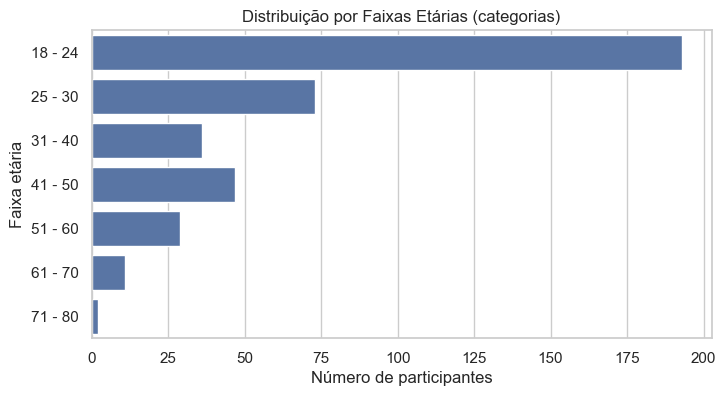

📊 Distribuição por Género dos Participantes:

        Frequência  Percentagem (%)
gender                             
F              221            56.52
M              167            42.71
O                3             0.77 



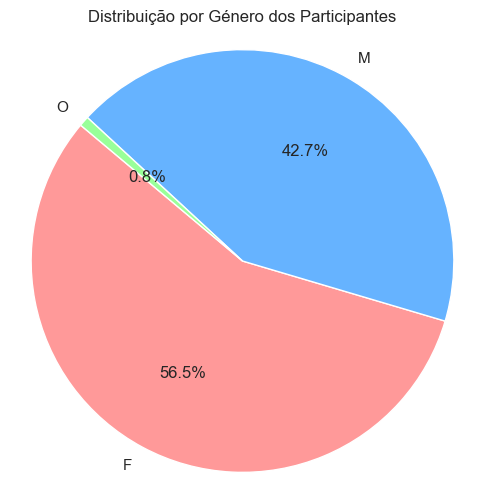

📊 Distribuição do Nível de Escolaridade dos Participantes:

                        Frequência  Percentagem (%)
education                                          
Bachelor’s Degree              200            51.15
Master’s Degree                 98            25.06
High School                     73            18.67
Doctorate Degree                13             3.32
Middle School                    6             1.53
Primary School or Less           1             0.26 



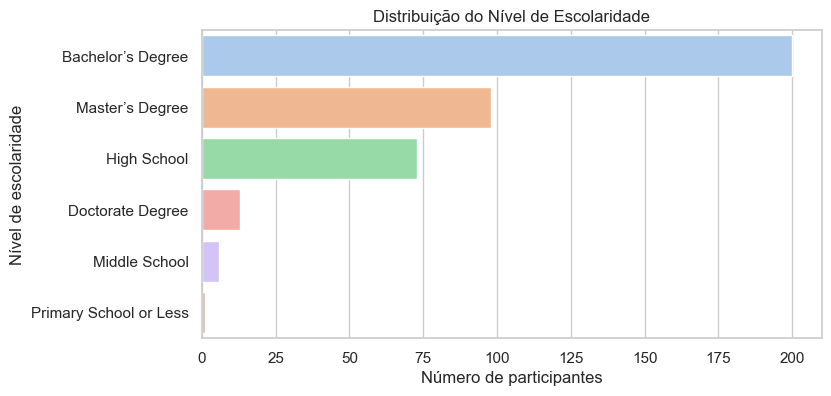

📊 Distribuição de Participantes por País de Residência

              País  Frequência
0         Portugal         349
1    United States          10
2   United Kingdom           8
3      Netherlands           4
4           Brazil           3
5     South Africa           2
6           Canada           2
7           Turkey           1
8       Luxembourg           1
9          Ireland           1
10         Denmark           1
11          Sweden           1
12           Italy           1
13         Finland           1
14     Afghanistan           1
15         Hungary           1
16           India           1
17     Philippines           1
18         Belgium           1
19  Czech Republic           1 



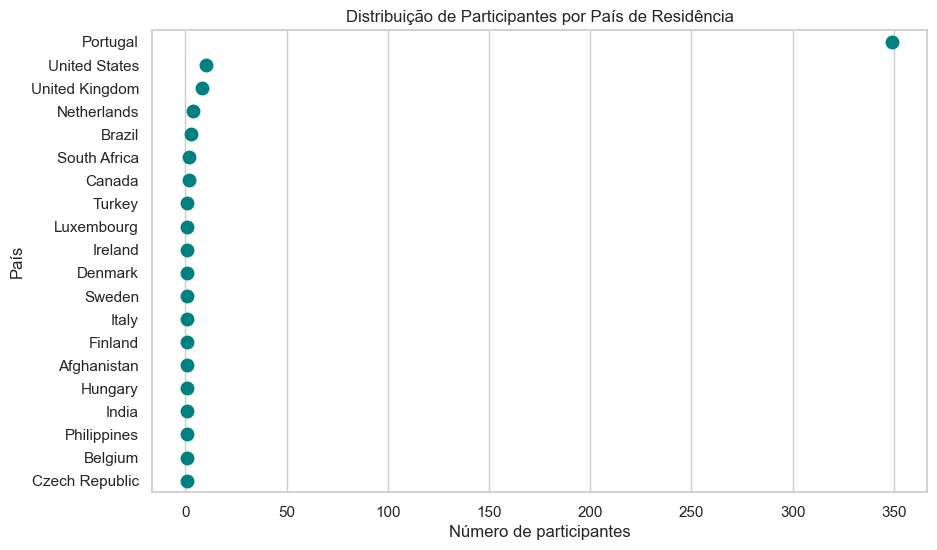

📊 Distribuição de Hobbies (palavra-chave, sem respostas vazias):

               Frequência  Percentagem (%)
hobby_keyword                             
Ginásio                13            18.84
Futebol                 8            11.59
Viajar                  5             7.25
Escrita                 4             5.80
Writing                 2             2.90
Ténis                   2             2.90
Padel                   2             2.90
Desporto                2             2.90
Surf                    2             2.90
Escalada                2             2.90
Marchas                 1             1.45
Volei                   1             1.45
Vários                  1             1.45
Yoga                    1             1.45
Outro                   1             1.45
Treino                  1             1.45
Cubo                    1             1.45
Voleibol                1             1.45
Musculação              1             1.45
Ginasio                 1      

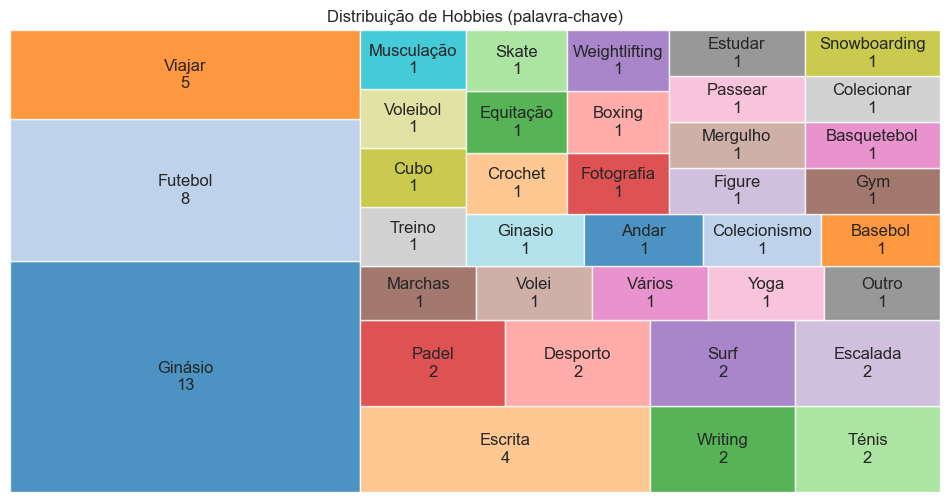

In [6]:
#INFORMAÇÔES DEMOGRÁFICAS DOS PARTICIPANTES

sns.set(style="whitegrid")
plt.rcParams.update({'figure.figsize': (8, 4)})

def parse_age_to_midpoint(age_val):
    """
    Converte strings de intervalo de idade para o ponto médio numérico.
    Exemplos aceites: '18 - 24', '18-24', '65+', 'Under 18', '18',  '30'
    Retorna np.nan se não conseguir converter.
    """
    if pd.isna(age_val):
        return np.nan
    if isinstance(age_val, (int, float, np.integer, np.floating)):
        return float(age_val)
    s = str(age_val).strip()
    # casos como '65+' ou '65 +'
    m = re.match(r'^(\d{1,3})\s*\+$', s)
    if m:
        low = int(m.group(1))
        # assumir + significa low..(low+10) por defeito -> ponto médio low+5
        return float(low + 5)
    # casos 'Under 18' ou 'under 18'
    m = re.match(r'^(under|<)\s*(\d{1,3})$', s, flags=re.I)
    if m:
        hi = int(m.group(2))
        return float(max(0, hi/2))
    # casos '18 - 24' ou '18-24'
    m = re.match(r'^(\d{1,3})\s*[-–]\s*(\d{1,3})$', s)
    if m:
        a, b = int(m.group(1)), int(m.group(2))
        return float((a + b) / 2.0)
    # caso seja apenas um número em string
    m = re.match(r'^(\d{1,3})$', s)
    if m:
        return float(int(m.group(1)))
    # não reconhecido
    return np.nan

# --- ANÁLISE DE IDADES ---
print("📊 Estatísticas iniciais da coluna 'age':")
print(df_surveys['age'].describe(), "\n")

# Se for object (strings) vamos mostrar counts por categoria
if df_surveys['age'].dtype == object or df_surveys['age'].dtype == 'O' or df_surveys['age'].dtype == 'string':
    print("A coluna 'age' contém valores categóricos/strings.\n")
    age_counts = df_surveys['age'].value_counts(dropna=False)
    age_percent = df_surveys['age'].value_counts(normalize=True, dropna=False) * 100
    df_age_table = pd.DataFrame({'Frequência': age_counts, 'Percentagem (%)': age_percent.round(2)})
    print(df_age_table, "\n")
    
    # Gráfico de barras (categorias)
    plt.figure()
    # ordenar categorias por ordem natural se possível (ex.: 'Under 18', '18 - 24', '25 - 34', ...)
    try:
        # tentativa de ordenar categorias por ponto médio
        cat_order = df_surveys['age'].dropna().unique().tolist()
        order_midpoints = {cat: parse_age_to_midpoint(cat) for cat in cat_order}
        # filtrar None e sort
        sorted_cats = sorted(cat_order, key=lambda c: (np.inf if np.isnan(order_midpoints[c]) else order_midpoints[c]))
        sns.countplot(y='age', data=df_surveys, order=sorted_cats)
    except Exception:
        sns.countplot(y='age', data=df_surveys, order=df_surveys['age'].value_counts().index)
    plt.title('Distribuição por Faixas Etárias (categorias)')
    plt.xlabel('Número de participantes')
    plt.ylabel('Faixa etária')
    plt.show()
    
    
# ANÁLISE DE GÉNERO
# --- Análise do Género com gráfico de pizza ---
if 'gender' in df_surveys.columns:
    print("📊 Distribuição por Género dos Participantes:\n")
    
    # Tabela de frequências e percentagens
    genero_counts = df_surveys['gender'].value_counts(dropna=False)
    genero_percent = genero_counts / genero_counts.sum() * 100
    df_genero_table = pd.DataFrame({'Frequência': genero_counts, 'Percentagem (%)': genero_percent.round(2)})
    print(df_genero_table, "\n")
    
    # Definir cores fixas por género
    color_map = {
        'F': '#ff9999',  # rosa
        'M': '#66b3ff',  # azul
        'O': '#99ff99',  # verde (outros)
        'NaN': '#ffcc99' # amarelo (sem resposta)
    }

    # Garantir que a cor segue a label correspondente
    colors = [color_map.get(label, '#cccccc') for label in genero_counts.index.astype(str)]

    # Gráfico de pizza
    plt.figure(figsize=(6,6))
    plt.pie(
        genero_counts,
        labels=genero_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors
    )
    plt.title('Distribuição por Género dos Participantes')
    plt.axis('equal')
    plt.show()
    
    
# ANÁLISE DE NÍVEL DE ESCOLARIDADE
# --- Análise do Nível de Escolaridade ---
if 'education' in df_surveys.columns:
    print("📊 Distribuição do Nível de Escolaridade dos Participantes:\n")
    
    # Tabela de frequências e percentagens
    edu_counts = df_surveys['education'].value_counts(dropna=False)
    edu_percent = df_surveys['education'].value_counts(normalize=True, dropna=False) * 100
    df_edu_table = pd.DataFrame({'Frequência': edu_counts, 'Percentagem (%)': edu_percent.round(2)})
    print(df_edu_table, "\n")
    
    # Ordena por frequência decrescente (mais seguro) ou podes definir ordem natural
    order_edu = edu_counts.index.tolist()
    
    # Gráfico de barras horizontal
    plt.figure(figsize=(8,4))
    sns.countplot(y='education', data=df_surveys, order=order_edu, palette='pastel')
    plt.title('Distribuição do Nível de Escolaridade')
    plt.xlabel('Número de participantes')
    plt.ylabel('Nível de escolaridade')
    plt.show()
    
# ANÁLISE DE REGIÃO/PAÍS
# --- Gráfico tipo "dot plot" para País de Residência ---

# Normalizar nomes das colunas
df_surveys.columns = df_surveys.columns.str.strip().str.lower()

# --- Dot plot para País de Residência ---
if 'country_residence' in df_surveys.columns:
    print("📊 Distribuição de Participantes por País de Residência\n")
    
    # Filtra apenas respostas válidas
    df_country = df_surveys[df_surveys['country_residence'].notna()]
    
    # Contagem por país
    country_counts = df_country['country_residence'].value_counts()
    df_country_table = pd.DataFrame({'País': country_counts.index, 'Frequência': country_counts.values})
    print(df_country_table, "\n")
    
    # --- Dot plot ---
    plt.figure(figsize=(10,6))
    sns.stripplot(x='Frequência', y='País', data=df_country_table, size=10, orient='h', color='teal')
    plt.title('Distribuição de Participantes por País de Residência')
    plt.xlabel('Número de participantes')
    plt.ylabel('País')
    plt.show()
    
# ANÁLIDE DE HOBBIES
# Normalizar nomes de colunas
df_surveys.columns = df_surveys.columns.str.strip().str.lower()

# --- Função para extrair palavra-chave do hobby ---
def extract_keyword(hobby_text):
    if pd.isna(hobby_text) or hobby_text.strip() == "":
        return "Sem resposta"
    text = hobby_text.lower()
    text = re.sub(r'[^a-zçãáéíóúâêô\s]', '', text)
    keyword = text.split()[0]
    return keyword.capitalize()

# Aplica a função à coluna hobby_other
df_surveys['hobby_keyword'] = df_surveys['hobby_other'].apply(extract_keyword)

# Frequências por palavra-chave, excluindo "Sem resposta"
hobby_counts = df_surveys[df_surveys['hobby_keyword'] != "Sem resposta"]['hobby_keyword'].value_counts()
hobby_percent = df_surveys[df_surveys['hobby_keyword'] != "Sem resposta"]['hobby_keyword'].value_counts(normalize=True) * 100
df_hobby_table = pd.DataFrame({'Frequência': hobby_counts, 'Percentagem (%)': hobby_percent.round(2)})

print("📊 Distribuição de Hobbies (palavra-chave, sem respostas vazias):\n")
print(df_hobby_table, "\n")

# Treemap
plt.ion()
plt.figure(figsize=(12,6))
squarify.plot(
    sizes=hobby_counts.values, 
    label=[f"{cat}\n{val}" for cat, val in zip(hobby_counts.index, hobby_counts.values)],
    alpha=0.8,
    color=plt.cm.tab20.colors
)
plt.axis('off')
plt.title('Distribuição de Hobbies (palavra-chave)')
plt.show()
    

📊 Percentage of each emotion in the total responses:
anger         4.20
fear         10.19
disgust       6.07
sadness      14.03
happiness    30.55
surprise     12.05
neutral      22.90
dtype: float64


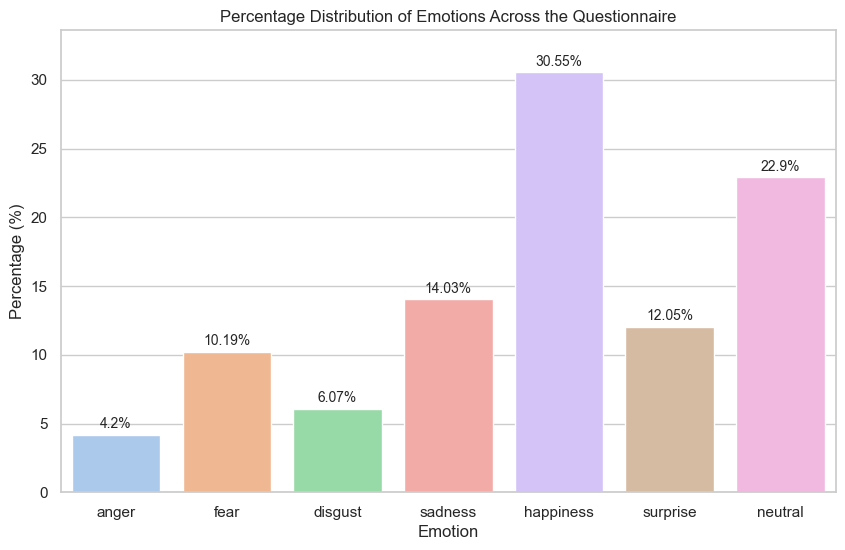

In [12]:
# ANÁLISE GERAL DE RESPOSTAS AO FORMS 

### 1 - Representação percentual de cada emoção em todo o questionário

# --- Lista de colunas emocionais ---
emotion_cols = ['anger', 'fear', 'disgust', 'sadness', 'happiness', 'surprise', 'neutral']

# --- Somatório de todas as respostas por emoção ---
total_emotions = df_ratings[emotion_cols].sum()
total_sum = total_emotions.sum()

# --- Percentagem de cada emoção ---
emotion_percent = (total_emotions / total_sum * 100).round(2)
print("📊 Percentage of each emotion in the total responses:")
print(emotion_percent)

# --- Gráfico de barras das percentagens ---
plt.figure(figsize=(10,6))
sns.barplot(x=emotion_percent.index, y=emotion_percent.values, palette='pastel')
plt.ylabel('Percentage (%)')
plt.xlabel('Emotion')
plt.title('Percentage Distribution of Emotions Across the Questionnaire')
plt.ylim(0, max(emotion_percent.values)*1.1)  # pequeno espaço acima da barra
for i, v in enumerate(emotion_percent.values):
    plt.text(i, v + 0.5, f"{v}%", ha='center', fontsize=10)
plt.show()



Número total de imagens únicas avaliadas: 1032
Imagens mais avaliadas:
id_photo
2441    23
2321    23
1678    23
1606    23
1108    23
1398    23
1826    23
2888    23
1347    23
2464    23
Name: count, dtype: int64
--------------------------
📊 Médias emocionais e afetivas por imagem (todas as imagens):
          anger  fear  disgust  sadness  happiness  surprise  neutral  \
id_photo                                                                
1           0.0  0.80     0.80      0.2       0.00      2.80     2.00   
2           0.0  3.09     1.09      0.0       0.36      1.09     0.00   
5           0.0  2.33     1.50      0.0       0.00      0.00     0.00   
6           0.0  2.40     0.00      0.0       0.00      1.60     0.00   
8           0.0  2.33     0.33      0.0       0.00      0.83     1.00   
11          0.0  0.40     0.00      0.0       0.00      0.60     2.20   
12          0.2  0.00     4.40      0.0       0.00      0.00     0.00   
13          0.0  2.40     1.20      0.

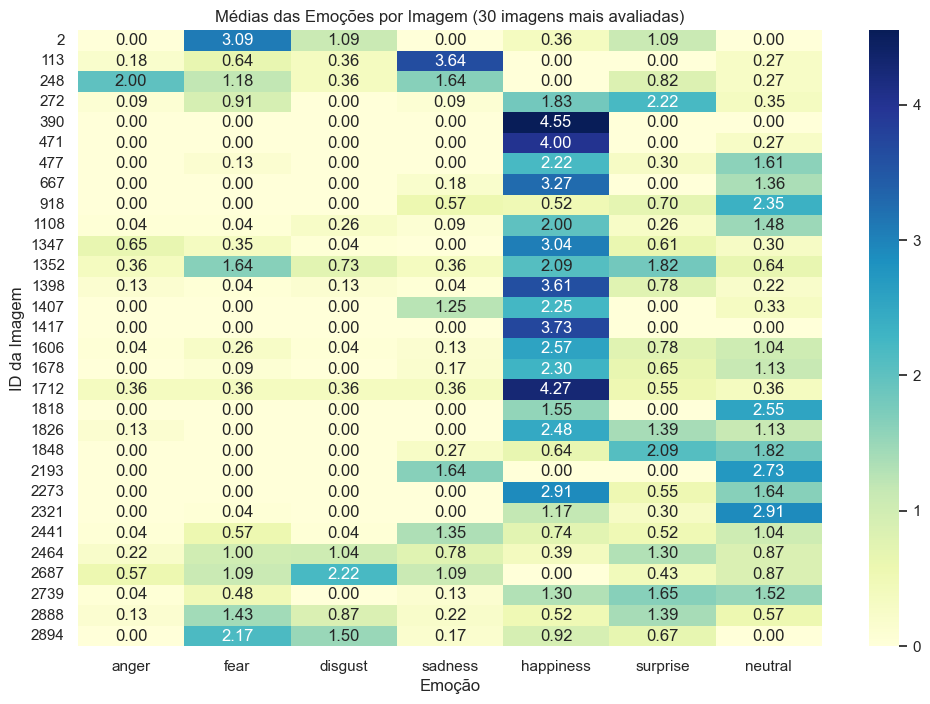

      n_avaliacoes  count
0             2441     23
1             2321     23
2             1678     23
3             1606     23
4             1108     23
...            ...    ...
1027          3037      5
1028           699      5
1029          1359      5
1030          1588      5
1031          2502      5

[1032 rows x 2 columns]


In [8]:
### ANÁLISE DE TODAS AS IMAGENS

# Contar frequência de cada imagem
image_counts = df_ratings['id_photo'].value_counts()
print(f"Número total de imagens únicas avaliadas: {len(image_counts)}")

# Mostrar as 10 primeiras apenas para referência
print("Imagens mais avaliadas:")
print(image_counts.head(10))
print("--------------------------")

# Colunas emocionais e afetivas
emotion_cols = ['anger', 'fear', 'disgust', 'sadness', 'happiness', 'surprise', 'neutral']
affective_cols = ['valence', 'arousal', 'dominance']

# --- Estatísticas médias por imagem (todas as imagens) ---
image_stats = df_ratings.groupby('id_photo')[emotion_cols + affective_cols].mean().round(2)

print("📊 Médias emocionais e afetivas por imagem (todas as imagens):")
print(image_stats.head(10))  # só mostra as primeiras para não ocupar muito

# --- Visualização: heatmap das emoções por imagem ---
# Se houver muitas imagens, o heatmap pode ficar ilegível -> mostra só as 30 mais avaliadas
num_imgs = len(image_stats)
if num_imgs > 30:
    top_imgs = df_ratings['id_photo'].value_counts().head(30).index
    img_subset = image_stats.loc[image_stats.index.isin(top_imgs)]
    title_suffix = " (30 imagens mais avaliadas)"
else:
    img_subset = image_stats
    title_suffix = " (todas as imagens)"

plt.figure(figsize=(12, 8))
sns.heatmap(img_subset[emotion_cols], annot=True, cmap='YlGnBu', fmt=".2f")
plt.title(f'Médias das Emoções por Imagem{title_suffix}')
plt.xlabel('Emoção')
plt.ylabel('ID da Imagem')
plt.show()

# --- Visualização: scatter plot valence

print(df_ratings['id_photo'].value_counts().reset_index().rename(columns={'index': 'id_photo', 'id_photo': 'n_avaliacoes'}))



Valores mínimo e máximo por emoção:
     anger  fear  disgust  sadness  happiness  surprise  neutral
min      0     0        0        0          0         0        0
max      5     5        5        5          5         5        5


Intensidade média dos agrupamentos emocionais:
          Intensidade Média
Negative           1.643478
Positive           1.455584
Neutral            1.090878
Surprise           0.573913 



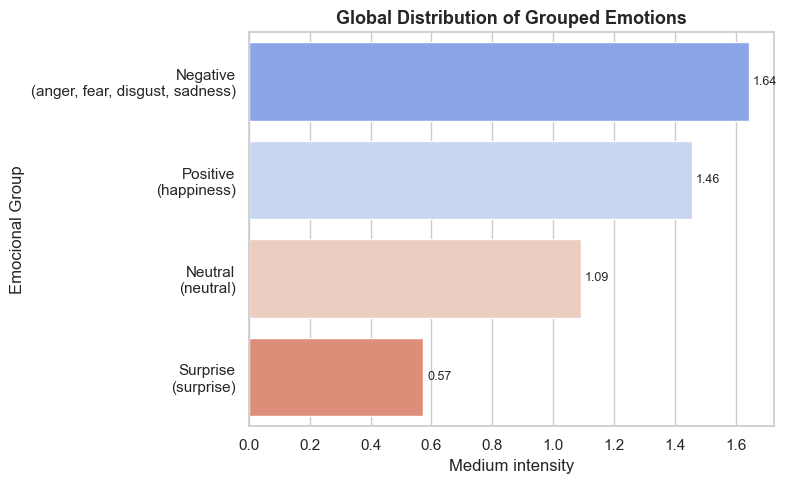

<Figure size 900x500 with 0 Axes>

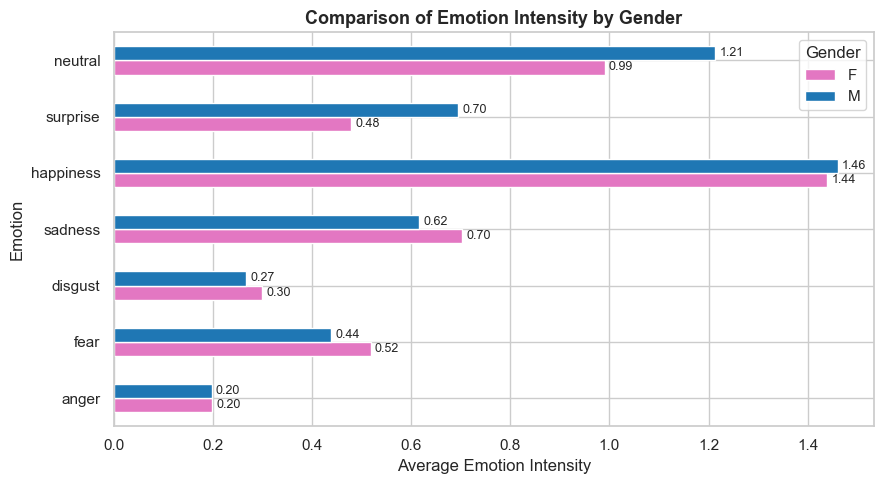

<Figure size 800x500 with 0 Axes>

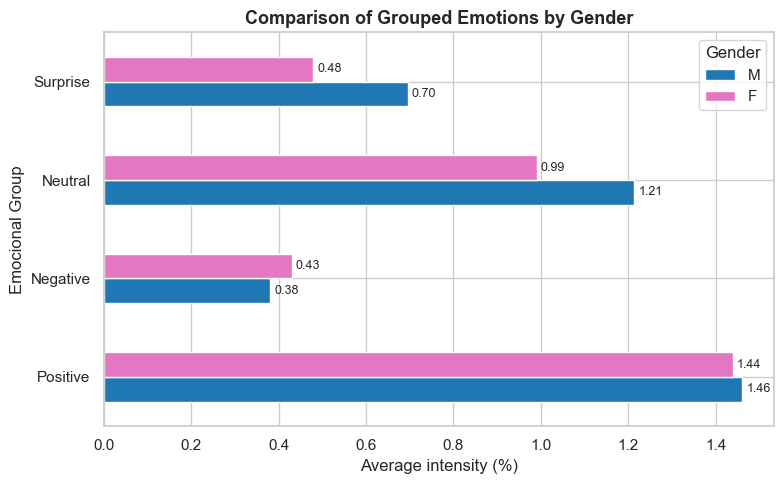

In [11]:
### 2 - Análise das emoções agrupadas

# --- Agrupamento das emoções ---
emotion_groups = {
    'Positive': ['happiness'],
    'Negative': ['anger', 'fear', 'disgust', 'sadness'],
    'Neutral': ['neutral'],
    'Surprise': ['surprise']
}

# --- Calcular médias ---
emotion_means = df_ratings[['anger','fear','disgust','sadness','happiness','surprise','neutral']].mean()
group_means = {group: emotion_means[emotions].sum() for group, emotions in emotion_groups.items()}

df_groups = pd.DataFrame.from_dict(group_means, orient='index', columns=['Intensidade Média'])
df_groups = df_groups.sort_values('Intensidade Média', ascending=False)

print("Valores mínimo e máximo por emoção:")
emotion_cols = ['anger', 'fear', 'disgust', 'sadness', 'happiness', 'surprise', 'neutral']
print(df_ratings[emotion_cols].agg(['min', 'max']))
print("\n")

print("Intensidade média dos agrupamentos emocionais:")
print(df_groups, "\n")

# --- Adicionar descrições das emoções (legenda interna) ---
labels_with_emotions = [
    f"{group}\n({', '.join(emotions)})"
    for group, emotions in emotion_groups.items()
]

# Reordenar as labels segundo a ordem de df_groups
labels_with_emotions = [
    f"{group}\n({', '.join(emotion_groups[group])})"
    for group in df_groups.index
]

# --- Gráfico ---
plt.figure(figsize=(8,5))
ax = sns.barplot(x=df_groups['Intensidade Média'], y=labels_with_emotions, palette='coolwarm')

# Adicionar valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=9, padding=3)

# --- Títulos e eixos ---
plt.title('Global Distribution of Grouped Emotions', fontsize=13, fontweight='bold')
plt.xlabel('Medium intensity')
plt.ylabel('Emocional Group')
plt.tight_layout()
plt.show()

#mesmo estilo de gráfico mas com as emoções separadas em vez de agrupadas, para comparar

# --- Definir emoções e géneros ---
emotion_cols = ['anger', 'fear', 'disgust', 'sadness', 'happiness', 'surprise', 'neutral']

# Combinar as tabelas ratings e surveys (para associar cada resposta ao género)
df_merge = pd.merge(df_ratings, df_surveys[['id', 'gender']], left_on='id_survey', right_on='id', how='inner')

# Calcular a média de intensidade por género e por emoção
gender_emotions = df_merge.groupby('gender')[emotion_cols].mean()

# Filtrar apenas M e F
gender_emotions = gender_emotions.loc[gender_emotions.index.isin(['M', 'F'])]

# Transpor para ter emoções nas linhas
gender_emotions = gender_emotions.T

# --- Visualização ---
plt.figure(figsize=(9, 5))

# Cores definidas manualmente (M = azul, F = rosa)
colors = {'M': '#1f77b4', 'F': '#e377c2'}

ax = gender_emotions.plot(
    kind='barh',
    figsize=(9, 5),
    color=[colors.get(col, '#cccccc') for col in gender_emotions.columns]
)

plt.title('Comparison of Emotion Intensity by Gender', fontsize=13, fontweight='bold')
plt.xlabel('Average Emotion Intensity')
plt.ylabel('Emotion')
plt.legend(title='Gender', loc='best')

# Adicionar rótulos de valores
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=9, padding=3)

plt.tight_layout()
plt.show()

# Gráfico 2: Comparação das Emoções Agrupadas por Género 

# Juntar ratings com género
df_merged = df_ratings.merge(df_surveys[['id', 'gender']], left_on='id_survey', right_on='id', how='left')

# Calcular médias 
gender_means = {}
for group, emotions in emotion_groups.items():
    gender_means[group] = df_merged.groupby('gender')[emotions].mean().mean(axis=1)


gender_means = pd.DataFrame(gender_means).T

# Filtrar apenas géneros M e F e definir cores
gender_means_filtered = gender_means[['M', 'F']].dropna(axis=0, how='all')

gender_colors = {
    'M': '#1f77b4',   # azul clássico
    'F': '#e377c2'    # rosa magenta suave
}

# --- Gráfico ---
plt.figure(figsize=(8,5))
ax = gender_means_filtered.plot(
    kind='barh',
    figsize=(8,5),
    color=[gender_colors.get(col, '#cccccc') for col in gender_means_filtered.columns]
)

plt.title('Comparison of Grouped Emotions by Gender', fontsize=13, fontweight='bold')
plt.xlabel('Average intensity (%)')
plt.ylabel('Emocional Group')
plt.legend(title='Gender', loc='best')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=9, padding=3)

plt.tight_layout()
plt.show()

# observação - diversificação de género nas respostas: 56.5 feminino & 42.7 masculino - então pq que aqui o Masculino tem mais respostas em todas as categorias?